<a href="https://colab.research.google.com/github/devyani-nandankar/devyani-nandankar.ML-practical.io/blob/main/ml_pract2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Devyani Nandankar CS23018

LAB1: TO IMPLEMENT lINEAR REGRESSION FOR PREDICTING CONTINUOUS TARGET VARIABLE AND EVALUATE THE MODEL PERFORMANCE USING APPROPRIATE METRICS

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Python program to generate a 3x3 Magic Square

def magic_square(n):
    magic = [[0 for _ in range(n)] for _ in range(n)]

    i = n // 2
    j = n - 1

    for num in range(1, n*n + 1):
        if i == -1 and j == n:
            i = 0
            j = n - 2
        else:
            if j == n:
                j = 0
            if i < 0:
                i = n - 1

        if magic[i][j] != 0:
            i = i + 1
            j = j - 2
            continue
        else:
            magic[i][j] = num

        i = i - 1
        j = j + 1

    return magic


# Driver code
n = 3
square = magic_square(n)

print("3x3 Magic Square:")
for row in square:
    print(row)

print("Magic Sum =", sum(square[0]))


3x3 Magic Square:
[2, 8, 7]
[0, 6, 1]
[5, 3, 9]
Magic Sum = 17


In [ ]:
# Step 1: Load Real Dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = housing.target    # Median house value

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


In [ ]:
df.shape

(20640, 9)

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
X = df.drop ('Target',axis=1)
y = df['Target']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=42)

In [ ]:
X_train.shape

(20598, 8)

In [ ]:
X_test.shape

(42, 8)

In [ ]:
y_train.shape

(20598,)

In [ ]:
y_test.shape

(42,)

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
# Step 5: Prediction

# Step 5: Prediction
y_pred = model.predict(X_test)



In [ ]:


# Step 6: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score (y_test, y_pred)

In [ ]:

print("\nModel Evaluation Metrics")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (RMSE):", rmse)
print("R^2 Score:",r2)


Model Evaluation Metrics
------------------------
Mean Absolute Error (MAE): 0.5404511416178702
Mean Squared Error (RMSE): 0.6128133591053131
R^2 Score: 0.6141160832615657


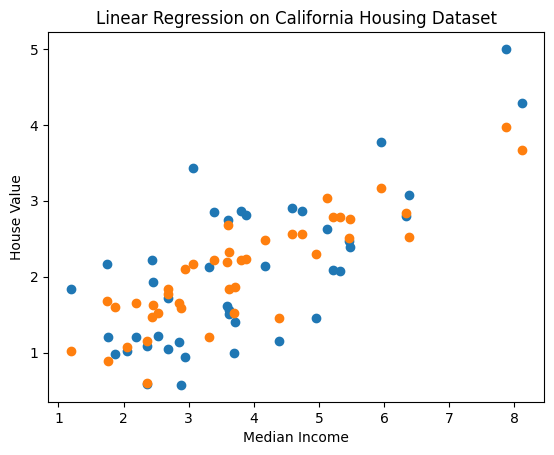

In [ ]:
# Step 7: Visualization (One Feature)
# ----------------------------------
plt.scatter(X_test['MedInc'], y_test)
plt.scatter(X_test['MedInc'], y_pred)
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Linear Regression on California Housing Dataset")
plt.show()